In [25]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator, PercentFormatter
from matplotlib.patches import Patch

from tokengt_paper_repo.pcqm4mv2_pyg import PygPCQM4Mv2Dataset
from torch_geometric.loader import DataLoader

from tokengt_experiments.motif_selection.zinc_smiles_dataset import ZincSmilesDataset

import torch
import random

warnings.filterwarnings('ignore')

# Suppress RDKit warnings
import rdkit
lg = rdkit.RDLogger.logger()
lg.setLevel(rdkit.RDLogger.CRITICAL)



In [26]:
def load_molecules(file_path, num_molecules=None):
    molecules = []
    smiles_list = []
    
    print(f"Loading first {num_molecules} molecules from {file_path}...")
    
    with open(file_path, 'r') as f:
        for i, line in enumerate(f):
            if num_molecules is not None and i >= num_molecules:
                break
            
            smiles = line.strip()
            mol = Chem.MolFromSmiles(smiles)
            
            if mol is not None:
                molecules.append(mol)
                smiles_list.append(smiles)
    
    print(f"Successfully loaded {len(molecules)} valid molecules")
    return molecules, smiles_list

def find_motif_matches(molecules, motif_mols, motif_smiles):
    results = defaultdict(list)

    for mol_idx, mol in enumerate(tqdm(molecules, desc="Processing molecules")):
        for motif_idx, motif_mol in enumerate(motif_mols):
            matches = mol.GetSubstructMatches(motif_mol)
            
            if matches:
                results[motif_smiles[motif_idx]].append({
                    'molecule_idx': mol_idx,
                    'num_matches': len(matches),
                    'match_positions': matches
                })
    
    return results


def analyze_motif_frequency(match_results, num_molecules):
    motif_stats = {}
    
    for motif_smiles, matches in match_results.items():
        molecules_with_motif = len(set(match['molecule_idx'] for match in matches))
        total_matches = sum(match['num_matches'] for match in matches)
        motif_stats[motif_smiles] = {
            'frequency': molecules_with_motif / num_molecules,
            'total_matches': total_matches,
            'avg_matches_per_mol': total_matches / molecules_with_motif if molecules_with_motif > 0 else 0,
            'molecules_with_motif': molecules_with_motif
        }
    
    return motif_stats


In [27]:

motif_file = "tokengt_experiments/motif_selection/clique.txt"
num_molecules = 1000
min_motif_size = 2
min_motif_frequency = 0.1

motifs, motif_smiles = load_molecules(motif_file)

Loading first None molecules from tokengt_experiments/motif_selection/clique.txt...
Successfully loaded 12233 valid molecules


In [ ]:
dataset = PygPCQM4Mv2Dataset(root="data/pcqm4m2/")
indices = random.sample(range(len(dataset)), num_molecules)
mol_smiles = [dataset[i].smiles for i in indices]
molecules = [Chem.MolFromSmiles(smiles) for smiles in mol_smiles]

In [28]:
dataset = ZincSmilesDataset(root="data/zinc/")
indices = random.sample(range(len(dataset)), num_molecules)
mol_smiles = [dataset[i].smiles for i in indices]
molecules = [Chem.MolFromSmiles(smiles) for smiles in mol_smiles]

Extracting data/zinc/molecules.zip
Processing...


Processing train split
Loaded 220011 molecules for train split
Loaded 220011 smiles


Processing train dataset: 100%|██████████| 220011/220011 [00:16<00:00, 13489.76it/s]


Processing val split
Loaded 24445 molecules for val split
Loaded 24445 smiles


Processing val dataset: 100%|██████████| 24445/24445 [00:03<00:00, 6285.22it/s] 


Processing test split
Loaded 5000 molecules for test split
Loaded 5000 smiles


Processing test dataset: 100%|██████████| 5000/5000 [00:00<00:00, 9555.35it/s] 
Done!


In [14]:
len(mol_smiles)

1000

In [29]:

match_results = find_motif_matches(molecules, motifs, motif_smiles)
motif_stats = analyze_motif_frequency(match_results, len(molecules))
motif_stats

Processing molecules: 100%|██████████| 1000/1000 [01:19<00:00, 12.65it/s]


{'CC': {'frequency': 0.997,
  'total_matches': 6702,
  'avg_matches_per_mol': 6.7221664994984955,
  'molecules_with_motif': 997},
 'CN': {'frequency': 0.944,
  'total_matches': 3925,
  'avg_matches_per_mol': 4.157838983050848,
  'molecules_with_motif': 944},
 'CCCC1CCCC2=CC=CC=C21': {'frequency': 0.001,
  'total_matches': 1,
  'avg_matches_per_mol': 1.0,
  'molecules_with_motif': 1},
 'CC1CCCC2=CC=CC=C21': {'frequency': 0.001,
  'total_matches': 2,
  'avg_matches_per_mol': 2.0,
  'molecules_with_motif': 1},
 'C1=CC=C2C(=C1)CCCC21CC1': {'frequency': 0.001,
  'total_matches': 1,
  'avg_matches_per_mol': 1.0,
  'molecules_with_motif': 1},
 'CCN': {'frequency': 0.915,
  'total_matches': 3385,
  'avg_matches_per_mol': 3.699453551912568,
  'molecules_with_motif': 915},
 'CC1CC1C': {'frequency': 0.015,
  'total_matches': 37,
  'avg_matches_per_mol': 2.466666666666667,
  'molecules_with_motif': 15},
 'C=O': {'frequency': 0.786,
  'total_matches': 1143,
  'avg_matches_per_mol': 1.45419847328244

In [47]:
motif_stats_smaller = {k: v for k, v in motif_stats.items() if v['frequency'] > 0.1}
print(f"Number of motifs with frequency > {min_motif_frequency}: {len(motif_stats_smaller)}")
motif_stats_smaller = {k: v for k, v in motif_stats_smaller.items() if Chem.MolFromSmiles(k).GetNumAtoms() >= min_motif_size}
print(f"Number of motifs with frequency > {min_motif_frequency} and num atoms >= {min_motif_size}: {len(motif_stats_smaller)}")
motif_stats_smaller

Number of motifs with frequency > 0.1: 45
Number of motifs with frequency > 0.1 and num atoms >= 2: 38


{'CC': {'frequency': 0.997,
  'total_matches': 6702,
  'avg_matches_per_mol': 6.7221664994984955,
  'molecules_with_motif': 997,
  'smiles': 'CC'},
 'CN': {'frequency': 0.944,
  'total_matches': 3925,
  'avg_matches_per_mol': 4.157838983050848,
  'molecules_with_motif': 944,
  'smiles': 'CN'},
 'CCN': {'frequency': 0.915,
  'total_matches': 3385,
  'avg_matches_per_mol': 3.699453551912568,
  'molecules_with_motif': 915,
  'smiles': 'CCN'},
 'C=O': {'frequency': 0.786,
  'total_matches': 1143,
  'avg_matches_per_mol': 1.4541984732824427,
  'molecules_with_motif': 786,
  'smiles': 'C=O'},
 'NC=O': {'frequency': 0.694,
  'total_matches': 1048,
  'avg_matches_per_mol': 1.5100864553314122,
  'molecules_with_motif': 694,
  'smiles': 'NC=O'},
 'CCC=O': {'frequency': 0.364,
  'total_matches': 594,
  'avg_matches_per_mol': 1.6318681318681318,
  'molecules_with_motif': 364,
  'smiles': 'CCC=O'},
 'CCCCC': {'frequency': 0.454,
  'total_matches': 1887,
  'avg_matches_per_mol': 4.156387665198238,
 

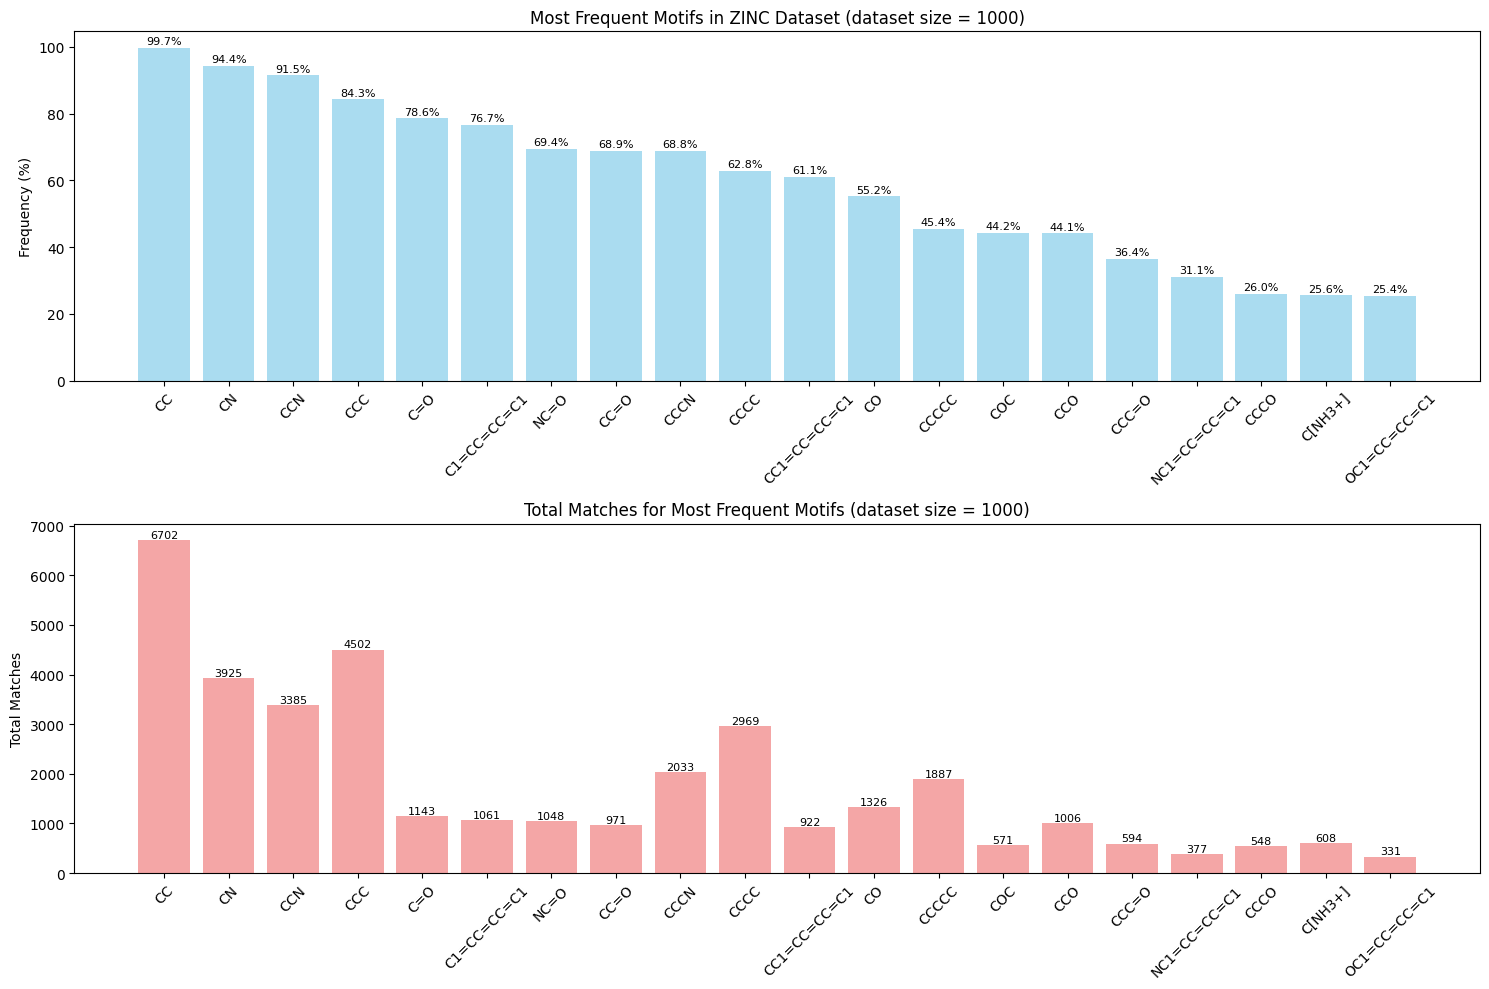

In [48]:
def visualize_motif_frequency(motif_stats, top_n=20):
    for key in motif_stats.keys():
        motif_stats[key]["smiles"] = key
    
    sorted_motifs = sorted(motif_stats.items(), 
                          key=lambda x: x[1]['frequency'], 
                          reverse=True)[:top_n]
    
    motifs = [item[0] for item in sorted_motifs]
    frequencies = [item[1]['frequency'] * 100 for item in sorted_motifs]
    
    plt.figure(figsize=(15, 10))
    
    # Create subplot for frequency
    plt.subplot(2, 1, 1)
    bars = plt.bar(range(len(motifs)), frequencies, color='skyblue', alpha=0.7)
    plt.ylabel('Frequency (%)')
    plt.title(f'Most Frequent Motifs in ZINC Dataset (dataset size = {num_molecules})')
    plt.xticks(range(len(motifs)), [motif_stats[motif]['smiles'] for motif in motifs], rotation=45)
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{frequencies[i]:.1f}%', ha='center', va='bottom', fontsize=8)
    
    # Create subplot for total matches
    total_matches = [item[1]['total_matches'] for item in sorted_motifs]
    plt.subplot(2, 1, 2)
    bars2 = plt.bar(range(len(motifs)), total_matches, color='lightcoral', alpha=0.7)
    plt.ylabel('Total Matches')
    plt.title(f'Total Matches for Most Frequent Motifs (dataset size = {num_molecules})')
    plt.xticks(range(len(motifs)), [motif_stats[motif]['smiles'] for motif in motifs], rotation=45)
    
    for i, bar in enumerate(bars2):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{total_matches[i]}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
visualize_motif_frequency(motif_stats_smaller, top_n=20)

In [49]:
num_matches = [motif_stats_smaller[key]["total_matches"] for key in motif_stats_smaller.keys()]
print(f"Total number of matches: {sum(num_matches)}")

Total number of matches: 41536


In [50]:
list(motif_stats_smaller.keys())

['CC',
 'CN',
 'CCN',
 'C=O',
 'NC=O',
 'CCC=O',
 'CCCCC',
 'CCCCCC',
 'CCCN',
 'CCO',
 'CCCC',
 'C1=CC=CC=C1',
 'CO',
 'CC=O',
 'CCC',
 'CCCO',
 'NCCO',
 'CC1=CC=CC=C1',
 'CF',
 'OC1=CC=CC=C1',
 'NC1=CC=CC=C1',
 'COC',
 'CS',
 'C1=CC=NC=C1',
 'CCS',
 'CCl',
 'NCN',
 'CC[NH3+]',
 'CCC[NH3+]',
 'CCCC[NH3+]',
 'C[NH3+]',
 'O=S',
 'CCCCO',
 'CN1CCCCC1',
 'CCCCC[NH3+]',
 'C1CCNCC1',
 'CCCCCO',
 'O=CO']

In [51]:
# ZINC

manually_cleaned_motifs = [
    # 'CC',
    # 'CN',
    # 'CCN',
    'C=O',
    'NC=O',
    # 'CCC=O',
    # 'CCCCC',
    # 'CCCCCC',
    # 'CCCN',
    # 'CCO',
    # 'CCCC',
    'C1=CC=CC=C1',
    # 'CO',
    # 'CC=O',
    # 'CCC',
    # 'CCCO',
    'NCCO',
    # 'CC1=CC=CC=C1',
    # 'CF',
    'OC1=CC=CC=C1',
    'NC1=CC=CC=C1',
    'COC',
    # 'CS',
    'C1=CC=NC=C1',
    # 'CCS',
    # 'CCl',
    'NCN',
    # 'CC[NH3+]',
    # 'CCC[NH3+]',
    # 'CCCC[NH3+]',
    # 'C[NH3+]',
    'O=S',
    # 'CCCCO',
    'CN1CCCCC1',
    # 'CCCCC[NH3+]',
    'C1CCNCC1',
    # 'CCCCCO',
    'O=CO']

In [12]:
# PCQM4M!!!!
manually_cleaned_motifs = [
    # 'CC',
    # 'CN',
    # 'CCN',
    # 'CCCCC',
    # 'CCCCCC',
    # 'CCCN',
    # 'CCCC',
    # 'CCC',
    'O=CO',
    'C=O',
    'NC=O',
    # 'CCO',
    'C1=CC=CC=C1',
    # 'CO',
    # 'CC=O',
    'NCCO',
    # 'CC1=CC=CC=C1',
    'COC',
    'C=N',
    # 'C=NC',
    'N=CO',
    # 'CC=N',
    # 'C=CCC',
    'C=C',
    # 'CCCO',
    # 'C=CC',
    # 'CCCCO',
    # 'CCCCCO',
    # 'CCC=O',
    # 'CS',
    'NC1=CC=CC=C1'
    ]
len(manually_cleaned_motifs)

10

In [52]:
manually_cleaned_stats = {k: v for k, v in motif_stats.items() if k in manually_cleaned_motifs}
manually_cleaned_stats

{'C=O': {'frequency': 0.786,
  'total_matches': 1143,
  'avg_matches_per_mol': 1.4541984732824427,
  'molecules_with_motif': 786,
  'smiles': 'C=O'},
 'NC=O': {'frequency': 0.694,
  'total_matches': 1048,
  'avg_matches_per_mol': 1.5100864553314122,
  'molecules_with_motif': 694,
  'smiles': 'NC=O'},
 'C1=CC=CC=C1': {'frequency': 0.767,
  'total_matches': 1061,
  'avg_matches_per_mol': 1.3833116036505868,
  'molecules_with_motif': 767,
  'smiles': 'C1=CC=CC=C1'},
 'NCCO': {'frequency': 0.206,
  'total_matches': 267,
  'avg_matches_per_mol': 1.296116504854369,
  'molecules_with_motif': 206,
  'smiles': 'NCCO'},
 'OC1=CC=CC=C1': {'frequency': 0.254,
  'total_matches': 331,
  'avg_matches_per_mol': 1.3031496062992125,
  'molecules_with_motif': 254,
  'smiles': 'OC1=CC=CC=C1'},
 'NC1=CC=CC=C1': {'frequency': 0.311,
  'total_matches': 377,
  'avg_matches_per_mol': 1.212218649517685,
  'molecules_with_motif': 311,
  'smiles': 'NC1=CC=CC=C1'},
 'COC': {'frequency': 0.442,
  'total_matches': 5

In [53]:
num_matches = [manually_cleaned_stats[key]["total_matches"] for key in manually_cleaned_stats.keys()]
print(f"Total number of matches: {sum(num_matches)}")

Total number of matches: 5735


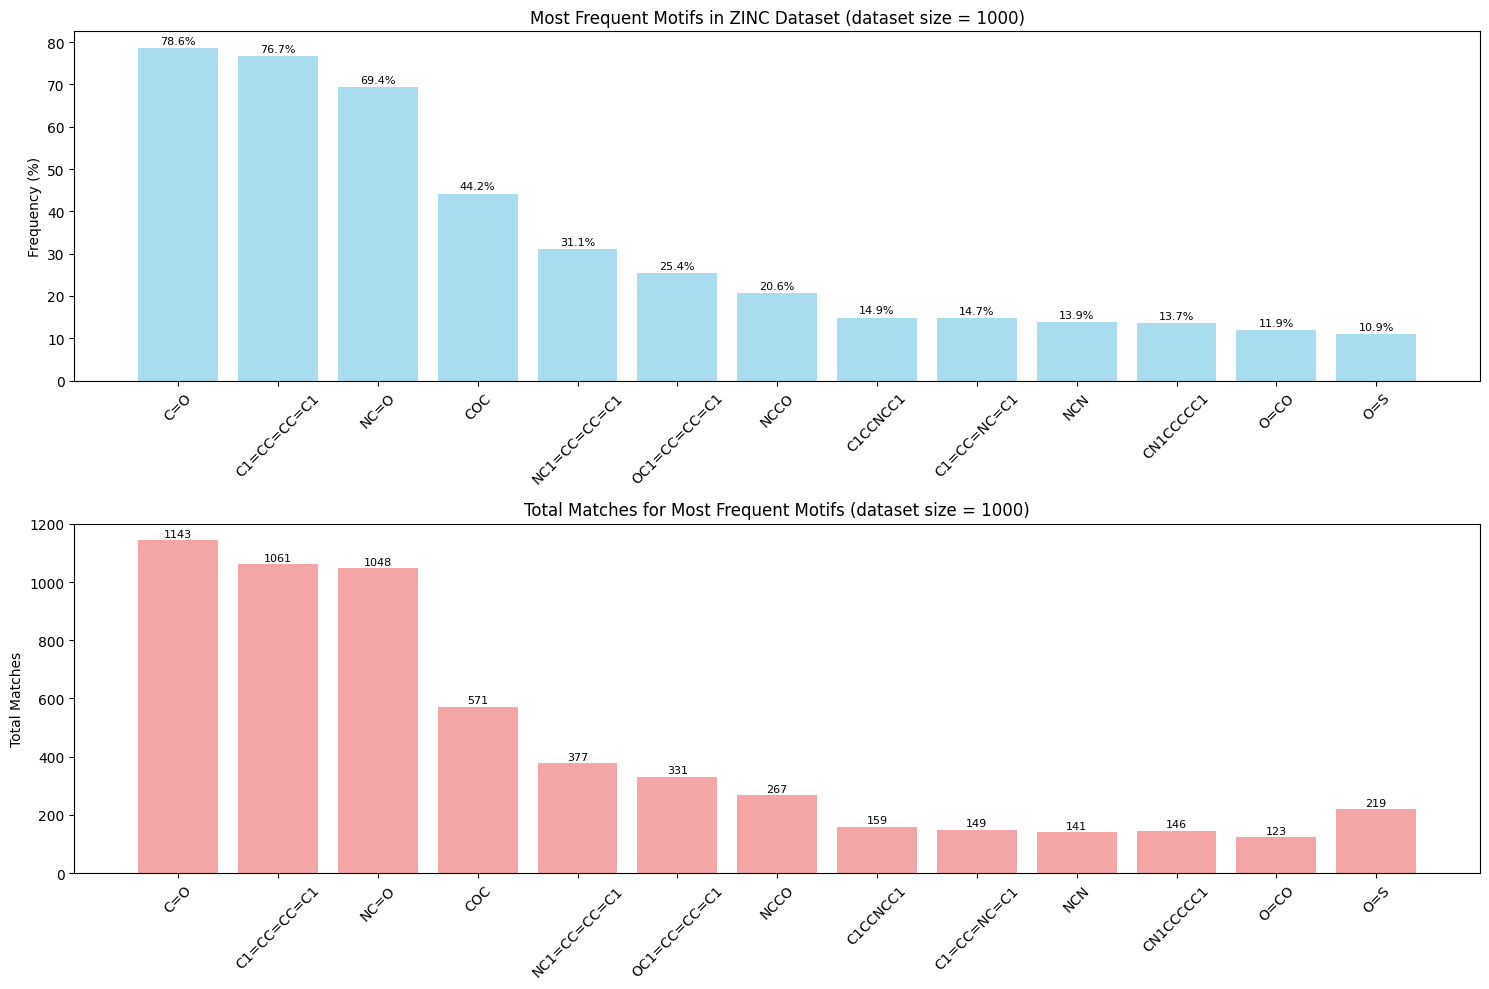

In [38]:
visualize_motif_frequency(manually_cleaned_stats, top_n=20)

In [25]:
num_matches = [manually_cleaned_stats[key]["total_matches"] for key in manually_cleaned_stats.keys()]
print(f"Total number of matches: {sum(num_matches)}")
print(f"Total number of motifs: {len(manually_cleaned_stats)}")

Total number of matches: 2469
Total number of motifs: 10


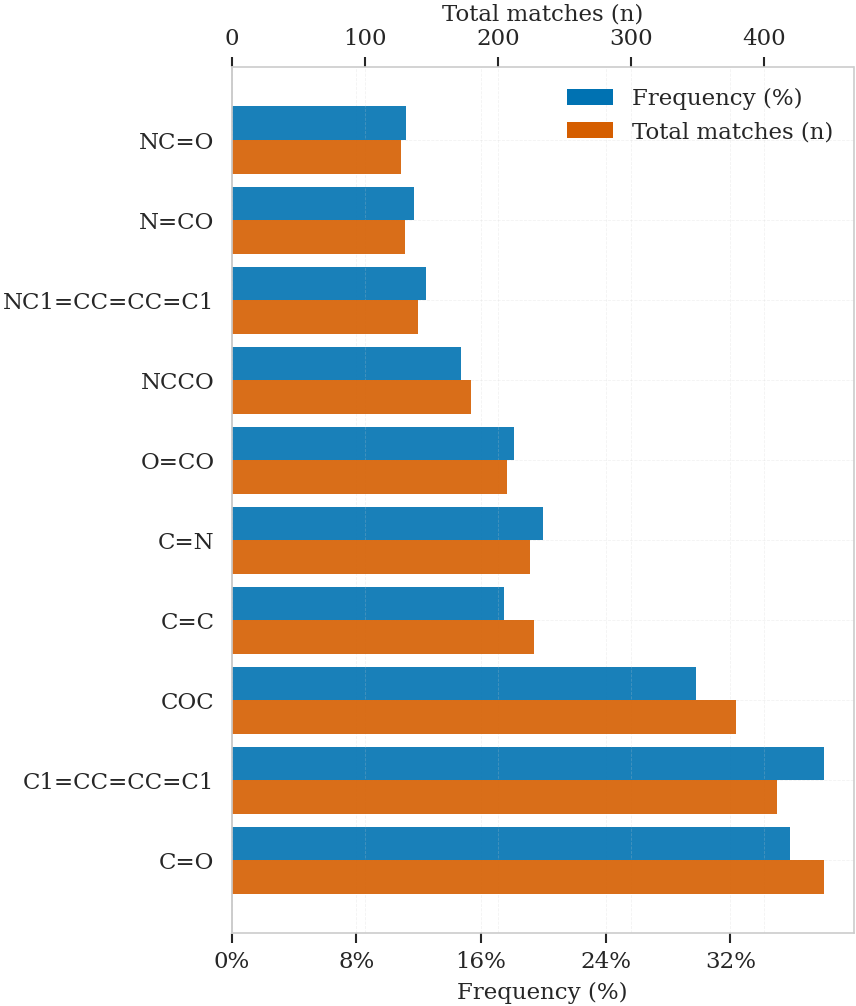

In [74]:
def plot_motif_dualbars(
    motif_stats,
    num_molecules,
    top_n=20,
):
    fig_width_in=6.0
    height_per_bar_in=0.32
    outfile="motifs_dualbars.pdf"
    palette=("#0072B2", "#D55E00")

    figure_height = max(1.6, height_per_bar_in * max(3, top_n) + 0.6)
    with mpl.rc_context({
        "figure.figsize": (fig_width_in, figure_height),
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "font.size": 11,
        "axes.titlesize": 11,
        "axes.labelsize": 11,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "font.family": "serif",
        "axes.linewidth": 0.8,
        "grid.linewidth": 0.4,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "legend.frameon": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }):
        rows = []
        for k, v in motif_stats.items():
            f = float(v["frequency"])
            pct = 100.0 * f
            n = v["total_matches"]
            rows.append((k, pct, n))

        rows.sort(key=lambda t: t[2], reverse=True)
        rows = rows[:top_n]

        motifs = [r[0] for r in rows][::-1]
        freq_pct = np.array([r[1] for r in rows], dtype=float)[::-1]
        counts = np.array([r[2] for r in rows], dtype=int)[::-1]

        y_labels = motifs

        freq_color, count_color = palette
        fig, ax_pct = plt.subplots()

        y = np.arange(len(motifs))
        bar_h = 0.42  # group height ~0.84

        b1 = ax_pct.barh(
            y - bar_h/2, freq_pct, height=bar_h, label="Frequency (%)",
            color=freq_color, alpha=0.9, edgecolor="none", zorder=3
        )
        ax_pct.set_xlabel("Frequency (%)")
        ax_pct.set_yticks(y)
        ax_pct.set_yticklabels(y_labels)
        ax_pct.invert_yaxis()
        ax_pct.xaxis.set_major_locator(MaxNLocator(5))
        ax_pct.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
        ax_pct.grid(axis="x", zorder=0)

        ax_cnt = ax_pct.twiny()
        b2 = ax_cnt.barh(
            y + bar_h/2, counts, height=bar_h, label="Total matches (n)",
            color=count_color, alpha=0.9, edgecolor="none", zorder=2
        )
        ax_cnt.set_xlabel("Total matches (n)")
        ax_cnt.xaxis.set_major_locator(MaxNLocator(5, integer=True))
        ax_cnt.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))

        legend_handles = [
            Patch(facecolor=freq_color, edgecolor="none", label="Frequency (%)"),
            Patch(facecolor=count_color, edgecolor="none", label="Total matches (n)"),
        ]
        ax_pct.legend(handles=legend_handles, loc="upper right")

        # ax_pct.set_title(f"The {len(motifs)} most frequent motifs in first {num_molecules:,} molecules of PCQM4Mv2")

        for spine in ["top", "right"]:
            ax_pct.spines[spine].set_visible(False)
        ax_cnt.spines["bottom"].set_visible(False)  # avoid double baseline

        fig.tight_layout()
        fig.savefig(outfile)
        return fig, (ax_pct, ax_cnt)

fig, ax = plot_motif_dualbars(manually_cleaned_stats, num_molecules=num_molecules, top_n=20)

